### Importing all the necessary libraries

```python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import requests
from io import StringIO

### Loading the dataset

In [2]:
dataset_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

response = requests.get(dataset_url)
print(response)
print('-----------------------')
print(response.text)

<Response [200]>
-----------------------
"Date","Temp"
"1981-01-01",20.7
"1981-01-02",17.9
"1981-01-03",18.8
"1981-01-04",14.6
"1981-01-05",15.8
"1981-01-06",15.8
"1981-01-07",15.8
"1981-01-08",17.4
"1981-01-09",21.8
"1981-01-10",20.0
"1981-01-11",16.2
"1981-01-12",13.3
"1981-01-13",16.7
"1981-01-14",21.5
"1981-01-15",25.0
"1981-01-16",20.7
"1981-01-17",20.6
"1981-01-18",24.8
"1981-01-19",17.7
"1981-01-20",15.5
"1981-01-21",18.2
"1981-01-22",12.1
"1981-01-23",14.4
"1981-01-24",16.0
"1981-01-25",16.5
"1981-01-26",18.7
"1981-01-27",19.4
"1981-01-28",17.2
"1981-01-29",15.5
"1981-01-30",15.1
"1981-01-31",15.4
"1981-02-01",15.3
"1981-02-02",18.8
"1981-02-03",21.9
"1981-02-04",19.9
"1981-02-05",16.6
"1981-02-06",16.8
"1981-02-07",14.6
"1981-02-08",17.1
"1981-02-09",25.0
"1981-02-10",15.0
"1981-02-11",13.7
"1981-02-12",13.9
"1981-02-13",18.3
"1981-02-14",22.0
"1981-02-15",22.1
"1981-02-16",21.2
"1981-02-17",18.4
"1981-02-18",16.6
"1981-02-19",16.1
"1981-02-20",15.7
"1981-02-21",16.6
"1981-02-

In [3]:
data = pd.read_csv(StringIO(response.text))
print(f"Dataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print("\nFirst few rows:")
print(data.head())

Dataset shape: (3650, 2)
Columns: ['Date', 'Temp']

First few rows:
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


To learn some basic statistics of the temperature data:

In [4]:
temp_column = data.columns[1]
print(temp_column)
temp = data[temp_column].values
print("Following are some basic statistics: ")

Temp
Following are some basic statistics: 


In [5]:
print(f"Min: {temp.min()}")
print("------------------------------------")
print(f"Max: {temp.max()}")
print("------------------------------------")
print(f"Mean: {temp.mean()}")
print("------------------------------------")
print(f"Std: {temp.std()}")
print("------------------------------------")
print(f"Total data points: {len(temp)}")
print("------------------------------------")

Min: 0.0
------------------------------------
Max: 26.3
------------------------------------
Mean: 11.177753424657535
------------------------------------
Std: 4.071279075310806
------------------------------------
Total data points: 3650
------------------------------------


### Building the autoregressive model

Defing the general autoregressive function that will take the series and the number of lag obeservations and returns the x and y matrices of the model

In [6]:
def autoregressive_model(series, lag):
    x = [] 
    y= []  
    for i in range(lag, len(series)):
        x.append(series[i-lag : i])
        y.append(series[i])
        
    return np.array(x), np.array(y)

In [7]:
lag_values = [1,2,3]
results = {}

for lag in lag_values:
    x, y = autoregressive_model(temp, lag)
    

    print(f"\nAR({lag}) Model:")
    print(f"X shape: {x.shape}")
    print(f"First 5 X values:\n{x[:5]}\n")
    print(f"y shape: {y.shape}")  
    print(f"First 5 y values:\n{y[:5]}\n")
    print(f"Data points available: {len(x)}")
    
    print(f"First 3 feature sets:")
    for i in range(min(3, len(x))):
        if lag == 1:
            print(f"  x[{i}]: {x[i][0]:.2f} -> y[{i}]: {y[i]:.2f}")
        else:
            print(f"  x[{i}]: {x[i]} -> y[{i}]: {y[i]:.2f}")
    
    split_idx = int(0.8 * len(x))
    
    x_train = x[:split_idx]
    x_test = x[split_idx:]
    y_train = y[:split_idx]
    y_test = y[split_idx:]
    
    results[lag] = {
        'x_train': x_train,
        'x_test': x_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    print(f"\nData Split for AR({lag}):")
    print(f"  Total samples: {len(x)}")
    print(f"  Training samples: {len(x_train)} ({len(x_train)/len(x)*100:.1f}%)")
    print(f"  Test samples: {len(x_test)} ({len(x_test)/len(x)*100:.1f}%)")
    print(f"  Training period: Day {lag+1} to {split_idx+lag}")
    print(f"  Test period: Day {split_idx+lag+1} to {len(x)+lag}")
    print("=" * 60)


AR(1) Model:
X shape: (3649, 1)
First 5 X values:
[[20.7]
 [17.9]
 [18.8]
 [14.6]
 [15.8]]

y shape: (3649,)
First 5 y values:
[17.9 18.8 14.6 15.8 15.8]

Data points available: 3649
First 3 feature sets:
  x[0]: 20.70 -> y[0]: 17.90
  x[1]: 17.90 -> y[1]: 18.80
  x[2]: 18.80 -> y[2]: 14.60

Data Split for AR(1):
  Total samples: 3649
  Training samples: 2919 (80.0%)
  Test samples: 730 (20.0%)
  Training period: Day 2 to 2920
  Test period: Day 2921 to 3650

AR(2) Model:
X shape: (3648, 2)
First 5 X values:
[[20.7 17.9]
 [17.9 18.8]
 [18.8 14.6]
 [14.6 15.8]
 [15.8 15.8]]

y shape: (3648,)
First 5 y values:
[18.8 14.6 15.8 15.8 15.8]

Data points available: 3648
First 3 feature sets:
  x[0]: [20.7 17.9] -> y[0]: 18.80
  x[1]: [17.9 18.8] -> y[1]: 14.60
  x[2]: [18.8 14.6] -> y[2]: 15.80

Data Split for AR(2):
  Total samples: 3648
  Training samples: 2918 (80.0%)
  Test samples: 730 (20.0%)
  Training period: Day 3 to 2920
  Test period: Day 2921 to 3650

AR(3) Model:
X shape: (3647,

### Splitting the dataset into training and testing sets

### Training the models

In [8]:
models = {}
performance = {}

for lag in lag_values:
    print(f"Training AR({lag}) model :")
    
    x_train = results[lag]['x_train']
    x_test = results[lag]['x_test']
    y_train = results[lag]['y_train']
    y_test = results[lag]['y_test']
    
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train,y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test,y_pred_test))
    
    models[lag] = model
    performance[lag] = {
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'y_true_train': y_train,
        'y_true_test': y_test
    }
    
    print(f"  Model coefficients: {model.coef_}")
    print(f"  Model intercept: {model.intercept_:.4f}")
    print(f"  Training RMSE: {train_rmse:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print("------------------------------------")

Training AR(1) model :
  Model coefficients: [0.76299884]
  Model intercept: 2.6296
  Training RMSE: 2.6191
  Test RMSE: 2.3767
------------------------------------
Training AR(2) model :
  Model coefficients: [0.07680224 0.70440882]
  Model intercept: 2.4274
  Training RMSE: 2.6118
  Test RMSE: 2.3689
------------------------------------
Training AR(3) model :
  Model coefficients: [ 0.18880855 -0.05689918  0.68993925]
  Model intercept: 1.9751
  Training RMSE: 2.5649
  Test RMSE: 2.3224
------------------------------------


In [9]:
print("\nRMSE Summary:")
print("------------------------------------")

for lag in lag_values:
    print(f"AR({lag}): Train = {performance[lag]['train_rmse']:.4f}, Test = {performance[lag]['test_rmse']:.4f}")


best_lag = min(lag_values, key=lambda x: performance[x]['test_rmse'])
print(f"\nBest model: AR({best_lag}) with Test RMSE = {performance[best_lag]['test_rmse']:.4f}")


RMSE Summary:
------------------------------------
AR(1): Train = 2.6191, Test = 2.3767
AR(2): Train = 2.6118, Test = 2.3689
AR(3): Train = 2.5649, Test = 2.3224

Best model: AR(3) with Test RMSE = 2.3224


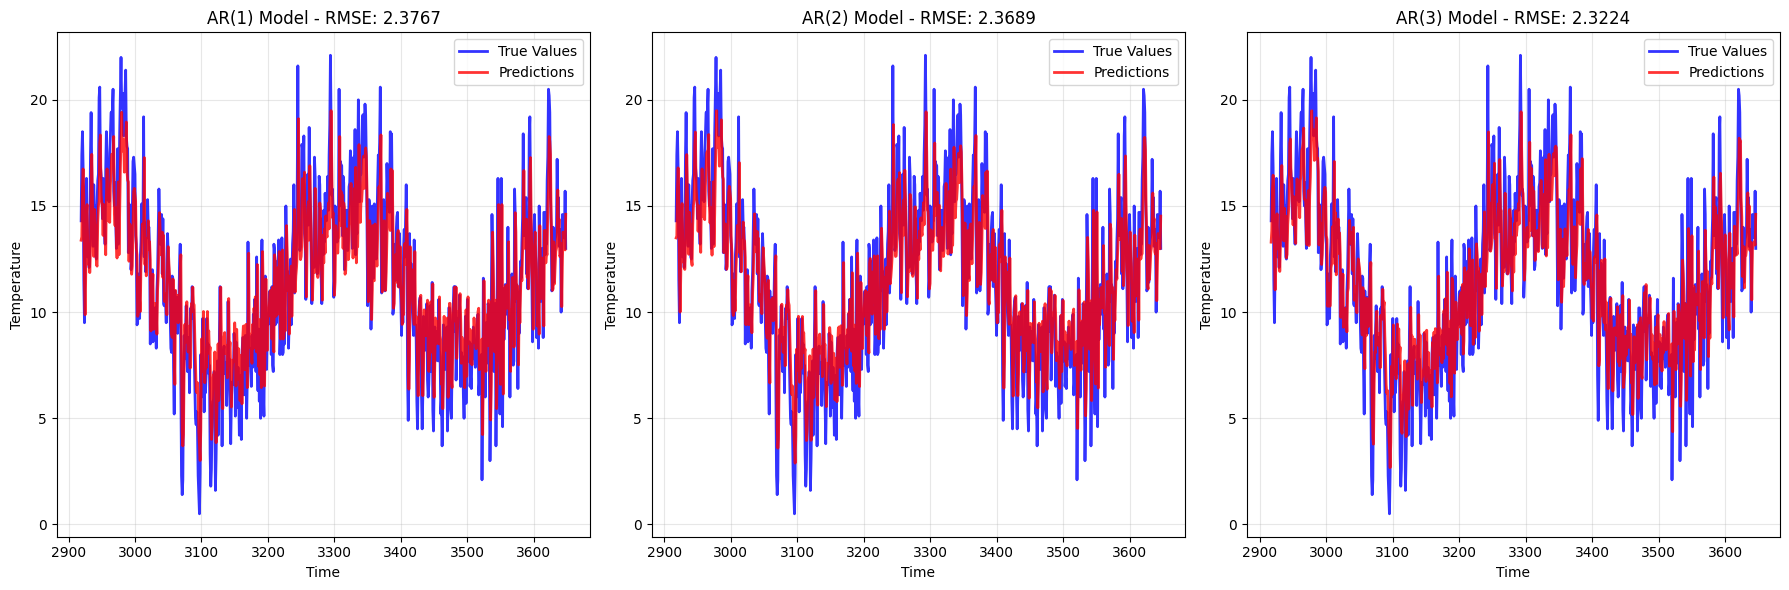

------------------------------------

Detailed plot for best model: AR(3)


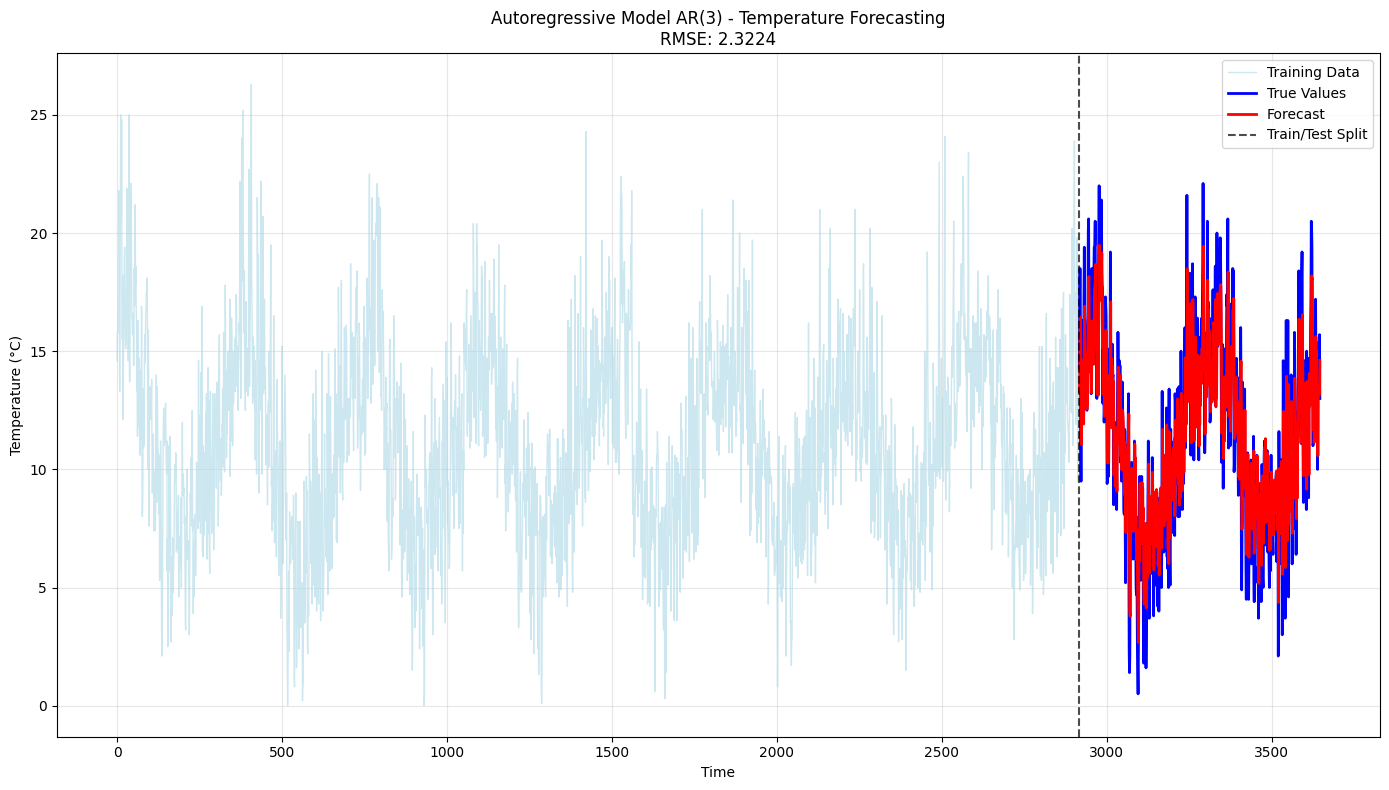

Best model AR(3) achieves RMSE of 2.3224 on test data


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, lag in enumerate(lag_values):
    ax = axes[idx]
    
    
    y_true_test = performance[lag]['y_true_test']
    y_pred_test = performance[lag]['y_pred_test']
    test_rmse = performance[lag]['test_rmse']
    
    test_start_idx = len(performance[lag]['y_true_train'])
    test_indices = np.arange(test_start_idx, test_start_idx + len(y_true_test))
    
    ax.plot(test_indices, y_true_test, 'b-', label='True Values', linewidth=2, alpha=0.8)
    ax.plot(test_indices, y_pred_test, 'r-', label='Predictions', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Temperature')
    ax.set_title(f'AR({lag}) Model - RMSE: {test_rmse:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("------------------------------------")

print(f"\nDetailed plot for best model: AR({best_lag})")
plt.figure(figsize=(14, 8))

y_true_train = performance[best_lag]['y_true_train']
y_true_test = performance[best_lag]['y_true_test']
y_pred_test = performance[best_lag]['y_pred_test']
best_rmse = performance[best_lag]['test_rmse']

train_indices = np.arange(len(y_true_train))
test_indices = np.arange(len(y_true_train), len(y_true_train) + len(y_true_test))

plt.plot(train_indices, y_true_train, 'lightblue', label='Training Data', alpha=0.6, linewidth=1)

plt.plot(test_indices, y_true_test, 'b-', label='True Values', linewidth=2)
plt.plot(test_indices, y_pred_test, 'r-', label='Forecast', linewidth=2)

plt.axvline(x=len(y_true_train), color='black', linestyle='--', alpha=0.7, label='Train/Test Split')

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title(f'Autoregressive Model AR({best_lag}) - Temperature Forecasting\nRMSE: {best_rmse:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best model AR({best_lag}) achieves RMSE of {best_rmse:.4f} on test data")